# ANUGA GPU Overland Flow Simulation

**GPU-accelerated rainfall-runoff simulation using ANUGA with CUDA.**

## ⚠️ CRITICAL Prerequisites

This notebook **requires GPU support**. Follow these steps carefully:

### 1. Install CuPy FIRST (before ANUGA)
CuPy must be installed **before** installing ANUGA so that ANUGA can detect CUDA support.

```powershell
# Check your CUDA version first:
nvidia-smi

# For CUDA 11.x:
pip install cupy-cuda11x

# For CUDA 12.x:
pip install cupy-cuda12x
```

**Verify CuPy installation:**
```powershell
python -c "import cupy as cp; print('CuPy version:', cp.__version__)"
```

### 2. Install ANUGA with CUDA Support
Once CuPy is installed, ANUGA will automatically enable GPU modules during installation:

```powershell
cd "e:\4th year\ANUGA-ing\anuga_core-main"
pip install -e .
```

**This compiles:**
- C/Cython extensions (`util_ext`, `neighbour_table_ext`, etc.)
- CUDA GPU modules (`sw_domain_cuda`) if CuPy is detected

### 3. Verify GPU Module Available
After installation, verify:
```powershell
python -c "from anuga.shallow_water.sw_domain_cuda import GPU_interface; print('GPU module OK')"
```

If you get `ModuleNotFoundError`, reinstall ANUGA after installing CuPy.

### 4. Other Dependencies
```powershell
pip install numpy scipy matplotlib pandas shapely gdal netcdf4
```

---

## 🚀 Running This Notebook

1. **Complete ALL installation steps above in order**
2. **Restart kernel** after installing CuPy and ANUGA
3. **Run cells in sequence** (Shift+Enter)
4. **Monitor GPU** during simulation:
   ```powershell
   nvidia-smi -l 1
   ```

---

## 🔧 Troubleshooting

**Error: `No module named 'anuga.shallow_water.sw_domain_cuda'`**
→ CuPy wasn't installed before ANUGA. Solution:
  1. `pip install cupy-cuda11x` (or cuda12x)
  2. Reinstall ANUGA: `cd anuga_core-main; pip install -e . --force-reinstall`

**Error: `ModuleNotFoundError: No module named 'anuga.utilities.util_ext'`**
→ ANUGA not compiled. Run `pip install -e .` in anuga_core-main folder

**GPU not detected**
→ Check CUDA with `nvidia-smi` and verify CuPy version matches CUDA version


In [1]:
# ===== ANUGA IMPORT WITH INSTALLATION CHECK =====
import sys, os, pathlib, time

# Check if anuga is properly installed (with compiled extensions)
print('Checking for ANUGA installation...')

try:
    import anuga
    print('✓ ANUGA imported successfully')
    print('  Location:', getattr(anuga, '__file__', 'unknown'))
    
    # Test for compiled extension (common failure point)
    try:
        from anuga.utilities.util_ext import gradient
        print('✓ Compiled extensions available')
    except ImportError:
        print('✗ WARNING: Compiled extensions missing!')
        print('  You need to install ANUGA with: pip install -e anuga_core-main')
        print('  (Run this in PowerShell from the anuga_core-main folder)')
        raise ImportError('ANUGA compiled extensions not available. See instructions in Cell 1 (markdown).')
    
except ImportError as e:
    print('✗ ANUGA not installed or installation incomplete')
    print()
    print('═' * 70)
    print('INSTALLATION REQUIRED')
    print('═' * 70)
    print('To use this notebook, you must install ANUGA with compiled extensions.')
    print()
    print('Steps:')
    print('1. Open PowerShell terminal in VS Code')
    print('2. Navigate to anuga_core-main folder:')
    print('   cd "e:\\4th year\\ANUGA-ing\\anuga_core-main"')
    print()
    print('3. Install ANUGA in development mode (builds extensions):')
    print('   pip install -e .')
    print()
    print('4. After installation completes, restart this notebook kernel')
    print('   (Kernel → Restart Kernel in VS Code menu)')
    print('═' * 70)
    print()
    raise ImportError('ANUGA not installed. Follow instructions above.') from e

Checking for ANUGA installation...
✗ ANUGA not installed or installation incomplete

══════════════════════════════════════════════════════════════════════
INSTALLATION REQUIRED
══════════════════════════════════════════════════════════════════════
To use this notebook, you must install ANUGA with compiled extensions.

Steps:
1. Open PowerShell terminal in VS Code
2. Navigate to anuga_core-main folder:
   cd "e:\4th year\ANUGA-ing\anuga_core-main"

3. Install ANUGA in development mode (builds extensions):
   pip install -e .

4. After installation completes, restart this notebook kernel
   (Kernel → Restart Kernel in VS Code menu)
══════════════════════════════════════════════════════════════════════



ImportError: ANUGA not installed. Follow instructions above.

In [10]:
# GPU detection (CuPy) and GDAL Windows fix
GPU_AVAILABLE = False
try:
    import cupy as cp
    GPU_AVAILABLE = True
    print('CuPy available:', cp.__version__)
except Exception as e:
    print('CuPy not available - will run on CPU.')
# Install CuPy matching your CUDA version to enable GPU.')

# GDAL/OSGeo DLL fix for some Windows conda envs
conda_library_bin = os.path.join(sys.prefix, 'Library', 'bin')
if os.path.exists(conda_library_bin):
    os.environ['PATH'] = conda_library_bin + os.pathsep + os.environ.get('PATH','')
    try:
        if hasattr(os, 'add_dll_directory'):
            os.add_dll_directory(conda_library_bin)
    except Exception:
        pass

print('Platform:', sys.platform, 'Python:', sys.version.split()[0])

CuPy available: 13.6.0
Platform: win32 Python: 3.13.7


In [11]:
# ===== SIMULATION CONFIGURATION =====
import numpy as np

class Config:
    def __init__(self):
        # Data files
        self.csv_file = 'bounder.csv'
        self.geotiff_file = 'DEM_UTM.tif'
        
        # Mesh resolution (smaller = more accurate but slower)
        self.maximum_triangle_area = 100000  # coarse for quick test
        
        # Physical parameters
        self.friction_coefficient = 0.03
        self.minimum_storable_height = 1e-5
        
        # Rainfall parameters
        self.rainfall_intensity_mm_hr = 10.0
        self.rainfall_duration_hours = 0.05  # 3 minutes
        
        # Simulation duration
        self.total_simulation_hours = 0.1  # 6 minutes total
        self.output_interval_minutes = 1.0
        
        # GPU setting (must be True - this notebook is GPU-only)
        self.use_gpu = True
        
        # Output settings
        self.output_dir = 'outputs'
        self.simulation_name = 'trial_gpu_test'

    def get_rainfall_rate_mps(self):
        """Convert rainfall from mm/hr to m/s."""
        return self.rainfall_intensity_mm_hr / (3600.0 * 1000.0)

config = Config()

print('Configuration:')
print(f'  Mesh area: {config.maximum_triangle_area:,} m²')
print(f'  Rainfall: {config.rainfall_intensity_mm_hr} mm/hr for {config.rainfall_duration_hours*3600:.0f}s')
print(f'  Simulation: {config.total_simulation_hours*3600:.0f}s')
print(f'  GPU mode: {"REQUIRED" if config.use_gpu else "OFF"}')

# Verify GPU is available
if config.use_gpu and not GPU_AVAILABLE:
    print('\n⚠ WARNING: GPU requested but CuPy not available!')
    print('  Install CuPy: pip install cupy-cuda11x  (or cupy-cuda12x)')
    print('  This notebook requires GPU acceleration to run.')


Configuration:
  Mesh area: 100,000 m²
  Rainfall: 10.0 mm/hr for 180s
  Simulation: 360s
  GPU mode: REQUIRED


In [12]:
# Build or load a polygon for domain creation (fallback to small square)
from shapely import wkt
import pandas as pd

def load_polygon_from_csv(csv_path):
    if not os.path.exists(csv_path):
        return None
    try:
        df = pd.read_csv(csv_path)
        wkt_string = df['WKT'].iloc[0]
        poly = wkt.loads(wkt_string)
        coords = [list(pt) for pt in poly.exterior.coords]
        if coords[0] == coords[-1]: coords.pop()
        return coords
    except Exception as e:
        print('Failed to parse polygon CSV:', e)
        return None

poly = load_polygon_from_csv(config.csv_file)
if poly is None:
    print('Using fallback small square polygon for a quick test')
    # small square (1000m side) as fallback
    cx = 0.0; cy = 0.0
    L = 1000.0
    poly = [[cx-L/2, cy-L/2],[cx+L/2, cy-L/2],[cx+L/2, cy+L/2],[cx-L/2, cy+L/2]]

print('Polygon vertices:', len(poly))

Polygon vertices: 4


In [ ]:
# ===== DOMAIN SETUP: CREATE MESH, CONFIGURE, LOAD DEM =====
import anuga
from anuga import create_domain_from_regions
from osgeo import gdal, osr

os.makedirs(config.output_dir, exist_ok=True)

# Helper function to extract zone/hemisphere from GeoTIFF
def get_tiff_zone_hemisphere(tiff_path):
    """Extract UTM zone and hemisphere from GeoTIFF."""
    if not os.path.exists(tiff_path):
        return None, None
    try:
        ds = gdal.Open(tiff_path)
        if ds is None:
            return None, None
        prj = ds.GetProjection()
        srs = osr.SpatialReference(wkt=prj)
        
        if srs.IsProjected():
            zone = srs.GetUTMZone()
            # Fallback parsing if GetUTMZone returns 0
            if zone == 0:
                name = srs.GetAttrValue('PROJCS')
                if name:
                    import re
                    match = re.search(r'zone\s+(\d+)', name, re.IGNORECASE)
                    if match:
                        zone = int(match.group(1))
            
            # Determine hemisphere from EPSG
            epsg = srs.GetAuthorityCode(None)
            hemisphere = 'northern'  # default
            if epsg:
                if epsg.startswith('327'):  # Southern hemisphere UTM codes
                    hemisphere = 'southern'
                elif epsg.startswith('326'):  # Northern hemisphere UTM codes
                    hemisphere = 'northern'
            
            return zone, hemisphere
        return None, None
    except Exception as e:
        print(f'Warning: Could not extract zone/hemisphere from {tiff_path}: {e}')
        return None, None

print('='*70)
print('DOMAIN SETUP')
print('='*70)

# 1. CREATE DOMAIN
print('\nCreating domain (this should be quick for the coarse mesh)...')
domain = create_domain_from_regions(
    poly, 
    boundary_tags={'exterior': list(range(len(poly)))}, 
    maximum_triangle_area=config.maximum_triangle_area
)
print(f'✓ Domain created with {domain.get_number_of_triangles():,} triangles')
print(f'  Domain area: {domain.get_area()/1e6:.2f} km²')

# 2. SET ZONE AND HEMISPHERE (BEFORE loading DEM)
zone_num, hemisphere = None, None
if os.path.exists(config.geotiff_file):
    zone_num, hemisphere = get_tiff_zone_hemisphere(config.geotiff_file)
    if zone_num and hemisphere:
        domain.geo_reference.set_zone(zone_num)
        domain.geo_reference.set_hemisphere(hemisphere)
        print(f'✓ Set zone={zone_num}, hemisphere={hemisphere} from DEM')
    else:
        print('⚠ Could not extract zone/hemisphere from DEM - using defaults')
        domain.geo_reference.set_zone(43)
        domain.geo_reference.set_hemisphere('northern')
        print('  Using fallback: zone=43, hemisphere=northern')
else:
    domain.geo_reference.set_zone(1)
    domain.geo_reference.set_hemisphere('northern')
    print('✓ No DEM - using generic zone=1, hemisphere=northern')

# 3. SET GPU-COMPATIBLE FLOW ALGORITHM
try:
    domain.set_flow_algorithm('DE0')
    domain.set_low_froude(0)
    print('✓ Flow algorithm: DE0 (GPU-compatible)')
except Exception:
    print('⚠ Could not set flow algorithm (older ANUGA version?)')

# 4. LOAD DEM OR SET FLAT ELEVATION
print('\nLoading topography...')
if os.path.exists(config.geotiff_file):
    try:
        domain.get_quantity('elevation').set_values_from_tif_file(config.geotiff_file)
        elev = domain.get_quantity('elevation')
        print(f'✓ DEM loaded: elevation range {elev.get_minimum_value():.2f} to {elev.get_maximum_value():.2f} m')
    except Exception as e:
        print(f'✗ Failed to load DEM: {e}')
        print('  Using flat elevation = 0')
        domain.set_quantity('elevation', 0.0)
else:
    print('DEM not found — using flat elevation = 0 for all cells')
    domain.set_quantity('elevation', 0.0)

# 5. SET INITIAL CONDITIONS
domain.set_quantity('friction', config.friction_coefficient)
domain.set_quantity('stage', expression='elevation')  # Dry bed
domain.set_minimum_storable_height(config.minimum_storable_height)
domain.set_name(config.simulation_name)
domain.set_datadir(config.output_dir)
print(f'✓ Initial conditions: dry bed, friction={config.friction_coefficient}')

# 6. SET BOUNDARY CONDITIONS
try:
    Bo = anuga.Dirichlet_boundary([-1.0, 0.0, 0.0])
    domain.set_boundary({'exterior': Bo})
    print('✓ Boundary: Dirichlet outflow')
except Exception as e:
    print(f'⚠ Could not set boundary: {e}')

# 7. INITIALIZE GPU INTERFACE (REQUIRES sw_domain_cuda MODULE)
print('\n' + '='*70)
print('GPU INITIALIZATION')
print('='*70)
gpu_interface = None

if not config.use_gpu:
    print('GPU disabled in config - using CPU mode')
    domain.set_multiprocessor_mode(1)
elif not GPU_AVAILABLE:
    print('✗ CuPy not available - GPU mode requires CuPy')
    print('  Install: pip install cupy-cuda11x  (or cupy-cuda12x)')
    domain.set_multiprocessor_mode(1)
else:
    # Try to import GPU module
    try:
        from anuga.shallow_water.sw_domain_cuda import GPU_interface
        print('✓ GPU module (sw_domain_cuda) imported successfully')
        
        # Initialize GPU interface following ANUGA CUDA examples
        try:
            # Start in CPU mode for initialization
            domain.set_multiprocessor_mode(1)
            
            # Update boundary once before GPU setup
            domain.update_boundary()
            
            # Create GPU interface
            print('  Creating GPU interface...')
            gpu_interface = GPU_interface(domain)
            
            # Allocate GPU arrays
            print('  Allocating GPU arrays...')
            gpu_interface.allocate_gpu_arrays()
            
            # Compile GPU kernels
            print('  Compiling GPU kernels (this may take 10-30 seconds)...')
            start_compile = time.time()
            gpu_interface.compile_gpu_kernels()
            compile_time = time.time() - start_compile
            print(f'  ✓ Kernels compiled in {compile_time:.1f}s')
            
            # Attach to domain
            domain.gpu_interface = gpu_interface
            
            # Switch to GPU mode
            domain.set_multiprocessor_mode(2)
            
            print('\n✓✓✓ GPU ACCELERATION ENABLED ✓✓✓')
            print(f'  Interface type: {type(gpu_interface).__name__}')
            
        except Exception as e:
            print(f'\n✗ GPU interface initialization failed: {e}')
            print('  Falling back to CPU mode')
            import traceback
            traceback.print_exc()
            domain.set_multiprocessor_mode(1)
            gpu_interface = None
            
    except ImportError as e:
        print('\n✗ CRITICAL: sw_domain_cuda module not found!')
        print('='*70)
        print('SOLUTION: Reinstall ANUGA with CUDA support')
        print('='*70)
        print('1. Install CuPy first (if not already installed):')
        print('   pip install cupy-cuda11x   # or cupy-cuda12x')
        print()
        print('2. Reinstall ANUGA (so it detects CuPy and builds GPU modules):')
        print('   cd "e:\\4th year\\ANUGA-ing\\anuga_core-main"')
        print('   pip install -e . --force-reinstall')
        print()
        print('3. Restart this notebook kernel')
        print('='*70)
        print('\nFalling back to CPU mode for now...')
        domain.set_multiprocessor_mode(1)

# Final status
print('\n' + '='*70)
print('DOMAIN READY')
print('='*70)
print(f'Triangles: {domain.get_number_of_triangles():,}')
mode = domain.get_multiprocessor_mode() if hasattr(domain, 'get_multiprocessor_mode') else 1
compute_mode = 'GPU (mode 2)' if mode == 2 else 'CPU (mode 1)'
print(f'Compute mode: {compute_mode}')
print(f'GPU interface: {"✓ Active" if gpu_interface is not None else "✗ None (CPU only)"}')
print('='*70)


DOMAIN SETUP

Creating domain (this should be quick for the coarse mesh)...
Setting omp_num_threads to 1
✓ Domain created with 163,087 triangles
  Domain area: 10634.47 km²
✓ Set zone=43, hemisphere=northern from DEM
✓ Flow algorithm: DE0 (GPU-compatible)

Loading topography...
Setting omp_num_threads to 1
✓ Domain created with 163,087 triangles
  Domain area: 10634.47 km²
✓ Set zone=43, hemisphere=northern from DEM
✓ Flow algorithm: DE0 (GPU-compatible)

Loading topography...
✓ DEM loaded: elevation range 0.00 to 265.99 m
✓ Initial conditions: dry bed, friction=0.03
✓ Boundary: Dirichlet outflow

Configuring GPU compute mode...
✗ GPU setup failed: No module named 'anuga.shallow_water.sw_domain_cuda'
  Falling back to CPU mode

DOMAIN READY
Triangles: 163,087
Compute mode: CPU (mode 1)
GPU interface: None
✓ DEM loaded: elevation range 0.00 to 265.99 m
✓ Initial conditions: dry bed, friction=0.03
✓ Boundary: Dirichlet outflow

Configuring GPU compute mode...
✗ GPU setup failed: No modul

In [14]:
# ===== EVOLVE WITH RAINFALL =====
print('='*70)
print('STARTING SIMULATION')
print('='*70)

# Setup rainfall operator
rainfall_rate = config.get_rainfall_rate_mps()
from anuga.operators.rate_operators import Rate_operator
rain_op = Rate_operator(
    domain, 
    rate=lambda t: rainfall_rate if t <= config.rainfall_duration_hours*3600 else 0.0
)

# Check compute mode
mode = domain.get_multiprocessor_mode() if hasattr(domain, 'get_multiprocessor_mode') else 1
using_gpu = (mode == 2) and (gpu_interface is not None)
print(f'\nCompute mode: {"GPU" if using_gpu else "CPU"}')
print(f'Rainfall: {config.rainfall_intensity_mm_hr} mm/hr for {config.rainfall_duration_hours*3600:.1f}s')
print(f'Total simulation time: {config.total_simulation_hours*3600:.1f}s')

# Short test evolve
print('\n--- Running short test evolve (0.5 seconds) ---')
start_time = time.time()
step_count = 0

try:
    for t in domain.evolve(yieldstep=0.1, finaltime=0.5):
        step_count += 1
        stage_range = domain.get_quantity('stage').get_values(location='centroids')
        print(f't={t:.3f}s | dt={domain.timestep:.6f}s | stage: [{stage_range.min():.4f}, {stage_range.max():.4f}]')
        
    elapsed = time.time() - start_time
    print(f'\n✓ Test evolve completed: {step_count} steps in {elapsed:.3f}s')
    
    # Show performance
    if step_count > 0:
        print(f'  Average: {elapsed/step_count:.4f}s per step')
    
except Exception as e:
    print(f'\n✗ Evolve failed: {e}')
    import traceback
    traceback.print_exc()

print('='*70)


STARTING SIMULATION

Compute mode: CPU
Rainfall: 10.0 mm/hr for 180.0s
Total simulation time: 360.0s

--- Running short test evolve (0.5 seconds) ---
t=0.000s | dt=0.000000s | stage: [0.0000, 265.9929]
t=0.100s | dt=0.100000s | stage: [0.0000, 265.9929]
t=0.000s | dt=0.000000s | stage: [0.0000, 265.9929]
t=0.100s | dt=0.100000s | stage: [0.0000, 265.9929]
t=0.200s | dt=0.100000s | stage: [0.0000, 265.9929]
t=0.300s | dt=0.100000s | stage: [0.0000, 265.9929]
t=0.200s | dt=0.100000s | stage: [0.0000, 265.9929]
t=0.300s | dt=0.100000s | stage: [0.0000, 265.9929]
t=0.400s | dt=0.100000s | stage: [0.0000, 265.9929]
t=0.500s | dt=0.100000s | stage: [0.0000, 265.9929]

✓ Test evolve completed: 6 steps in 0.945s
  Average: 0.1575s per step
t=0.400s | dt=0.100000s | stage: [0.0000, 265.9929]
t=0.500s | dt=0.100000s | stage: [0.0000, 265.9929]

✓ Test evolve completed: 6 steps in 0.945s
  Average: 0.1575s per step


In [15]:
# Quick diagnostic: print GPU interface summary if present
if getattr(domain, 'gpu_interface', None) is not None:
    print('GPU interface type:', type(domain.gpu_interface))
    try:
        import cupy as cp
        mem = cp.get_default_memory_pool().used_bytes() / 1e6
        print(f'CuPy memory used: {mem:.1f} MB')
    except Exception:
        pass
else:
    print('No GPU interface attached to domain')

No GPU interface attached to domain


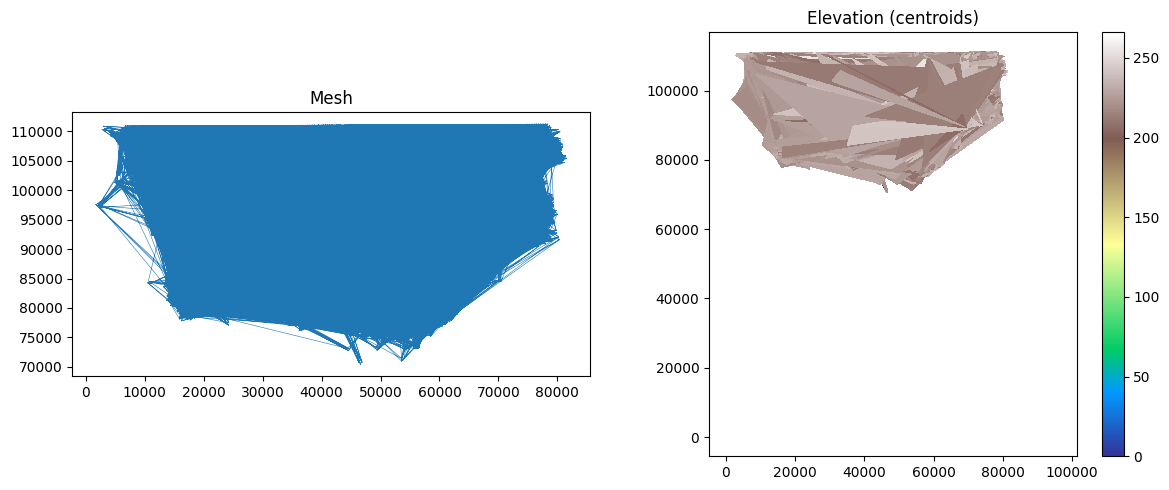

In [16]:
# Plot the mesh and elevation (simple)
import matplotlib.pyplot as plt
import matplotlib.tri as tri
pts = domain.get_vertex_coordinates()
tris = domain.get_triangles()
x = pts[:,0]; y = pts[:,1]
triang = tri.Triangulation(x, y, tris)
elev_vals = domain.get_quantity('elevation').get_values(location='centroids')

fig, ax = plt.subplots(1,2, figsize=(12,5))
ax[0].triplot(triang, lw=0.4)
ax[0].set_title('Mesh')
ax[0].set_aspect('equal')
tcf = ax[1].tripcolor(triang, elev_vals, shading='flat', cmap='terrain')
ax[1].set_title('Elevation (centroids)')
ax[1].set_aspect('equal')
fig.colorbar(tcf, ax=ax[1])
plt.tight_layout()
plt.show()

## Notes & Next Steps
- If you want to run longer simulations, increase `config.total_simulation_hours` and set an appropriate `maximum_triangle_area` in the configuration cell.
- To use the full GPU kernels reliably on Windows, ensure CUDA toolkit and a matching `cupy-cuda*` package are installed.
- If ANUGA fails to find `sw_domain_cuda`, either install the development package (`pip install -e anuga_core-main`) or ensure `anuga_core-main` is added to `sys.path`.